<a href="https://colab.research.google.com/github/mahathirumalathi97-web/Cross-Market-Analysis/blob/main/SQL_Queries_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
conn = sqlite3.connect('Global.db')
print("Connected to in-memory database")

Connected to in-memory database


In [ ]:
df1=pd.read_csv("/content/df_Literacy.csv")
df2=pd.read_csv("/content/df_Illiteracy.csv")
df3=pd.read_csv("/content/df_Gdp_Schooling.csv")

# SQL QUERIES WITH VISUALIZATION

# literacy_rates
1.Get top 5 countries with highest adult literacy in 2020.

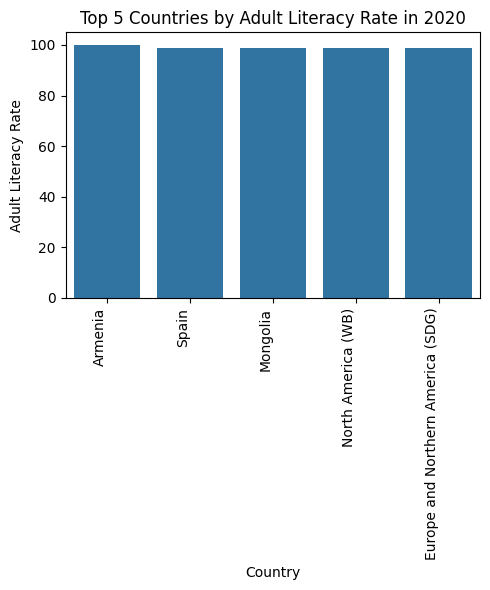

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_top_countries = pd.read_sql("""SELECT Country_X, MAX(adult_literacy_rate_population) AS adult_literacy_rate
    FROM literacy_rates
    WHERE year = 2020
    GROUP BY Country_X
    ORDER BY adult_literacy_rate DESC
    LIMIT 5;
    """, conn)

plt.figure(figsize=(5,6))
sns.barplot(x="Country_X", y="adult_literacy_rate", data=df_top_countries)
plt.title("Top 5 Countries by Adult Literacy Rate in 2020")
plt.xlabel("Country")
plt.ylabel("Adult Literacy Rate")
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

# 2.Find countries where female youth literacy < 80%.

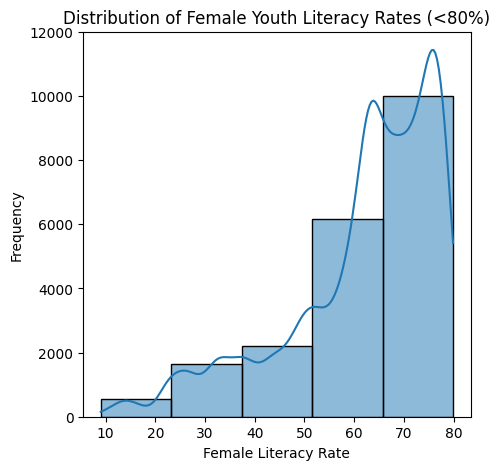

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_sql("""
SELECT Country_Y, female, year
FROM literacy_rates
WHERE female < 80
ORDER BY female DESC
""", conn)

plt.figure(figsize=(5,5))
sns.histplot(df["female"], bins=5, kde=True)
plt.title("Distribution of Female Youth Literacy Rates (<80%)")
plt.xlabel("Female Literacy Rate")
plt.ylabel("Frequency")
plt.show()

# 3.Average adult literacy per continent (owid region).

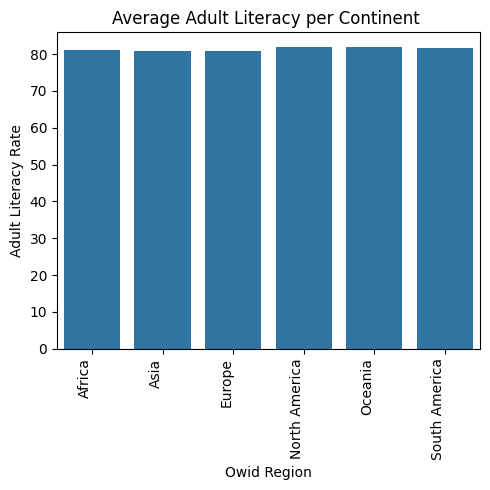

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

adult_literacy = pd.read_sql("""SELECT owid_region_y, AVG(adult_literacy_rate_population) AS avg_adult_literacy
    FROM Literacy_rates
    GROUP BY owid_region_y;
    """, conn)
plt.figure(figsize=(5,5))
sns.barplot(
    data=adult_literacy,
    x="owid_region_y",
    y="avg_adult_literacy"
)

plt.title("Average Adult Literacy per Continent ")
plt.xlabel("Owid Region")
plt.ylabel("Adult Literacy Rate")
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

# illiteracy_population
     4. Countries with illiteracy % > 20% in 2000.

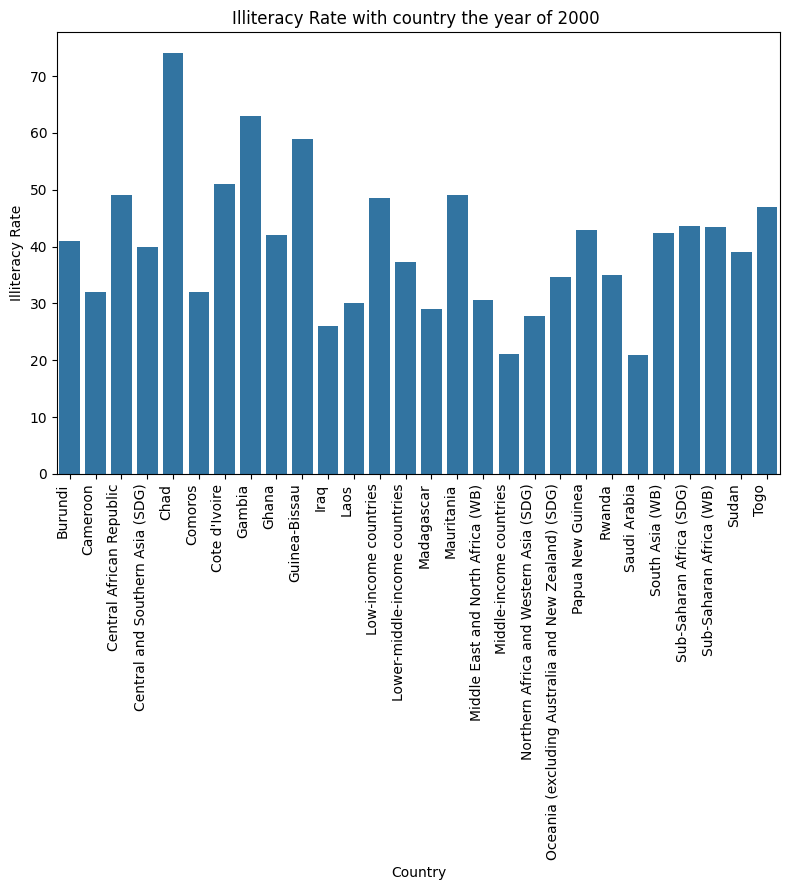

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Illiteracy=pd.read_sql("""
select
Country_Z,illiteracy_rate
FROM illiteracy_population
where illiteracy_rate > 20
and year = 2000
;""", conn
)
plt.figure(figsize=(8,9))
sns.barplot(
    data=Illiteracy,
    x="Country_Z",
    y="illiteracy_rate"
)

plt.title("Illiteracy Rate with country the year of 2000 ")
plt.xlabel("Country")
plt.ylabel("Illiteracy Rate")
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

# 5. Trend of illiteracy % for India (2000–2020).

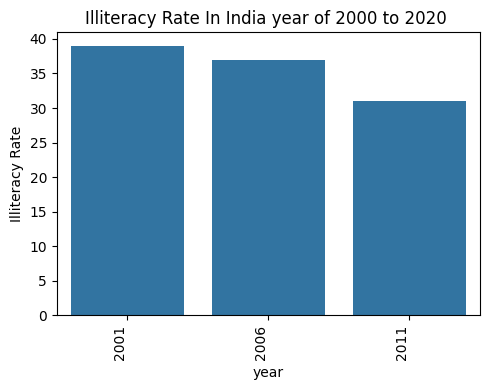

In [ ]:
Illiteracy=pd.read_sql("""
select
Country_Z,illiteracy_rate, year
FROM illiteracy_population
where Country_Z = 'India'
and year >= 2000 and year <= 2020
order by year;
""", conn
)

plt.figure(figsize=(5,4))
sns.barplot(
    data=Illiteracy,
    x="year",
    y="illiteracy_rate"
)

plt.title("Illiteracy Rate In India year of 2000 to 2020 ")
plt.xlabel("year")
plt.ylabel("Illiteracy Rate")
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

# 6. Top 10 countries with largest illiterate population in the last year.

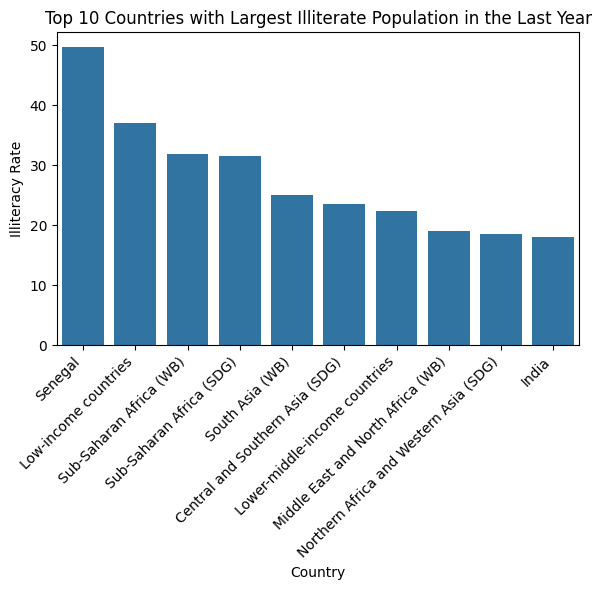

In [ ]:
df=pd.read_sql("""
SELECT
Country_Z,illiteracy_rate,year
FROM illiteracy_population
WHERE year = (SELECT MAX(year) FROM illiteracy_population)
ORDER BY illiteracy_rate DESC
LIMIT 10;
""",conn
 )

plt.figure(figsize=(6,6))
sns.barplot(
    data=df,
    x="Country_Z",
    y="illiteracy_rate"
)
plt.title("Top 10 Countries with Largest Illiterate Population in the Last Year")
plt.xlabel("Country")
plt.ylabel("Illiteracy Rate")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# gdp_schooling
    7. Find countries with avg_years_schooling > 7 and gdp_per_capita < 5000.

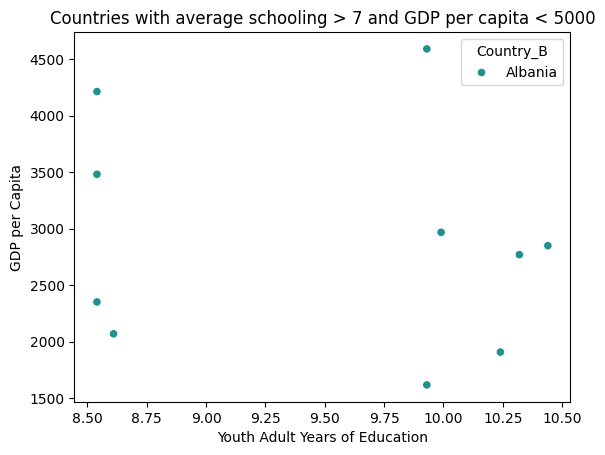

In [ ]:
data=pd.read_sql("""
SELECT
Country_B,youth_adult_yr_edu,gdp_per_capita
FROM Gdp_Schooling
WHERE youth_adult_yr_edu > 7 AND gdp_per_capita < 5000
ORDER BY Country_B
LIMIT 10;
""",conn )

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=data, x="youth_adult_yr_edu", y="gdp_per_capita", hue="Country_B", palette="viridis")
plt.title("Countries with average schooling > 7 and GDP per capita < 5000")
plt.xlabel("Youth Adult Years of Education")
plt.ylabel("GDP per Capita")
plt.show()

 #  8. Rank countries by GDP per schooling for the year 2020.

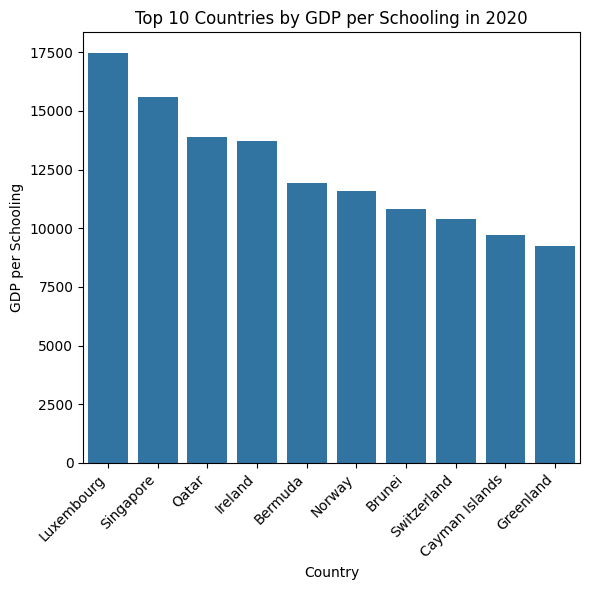

In [ ]:
df=pd.read_sql("""
SELECT
  Country_A,
  AVG(gdp_per_capita / youth_adult_yr_edu) as gdp_per_schooling,
  RANK() OVER(ORDER BY AVG(gdp_per_capita / youth_adult_yr_edu) DESC) as country_rank
FROM Gdp_Schooling
WHERE year = 2020
GROUP BY Country_A
ORDER BY gdp_per_schooling DESC;
""",conn)

plt.figure(figsize=(6,6))
sns.barplot(data=df.head(10), x="Country_A", y="gdp_per_schooling")
plt.title("Top 10 Countries by GDP per Schooling in 2020")
plt.xlabel("Country")
plt.ylabel("GDP per Schooling")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#  9. Find global average schooling years per year.

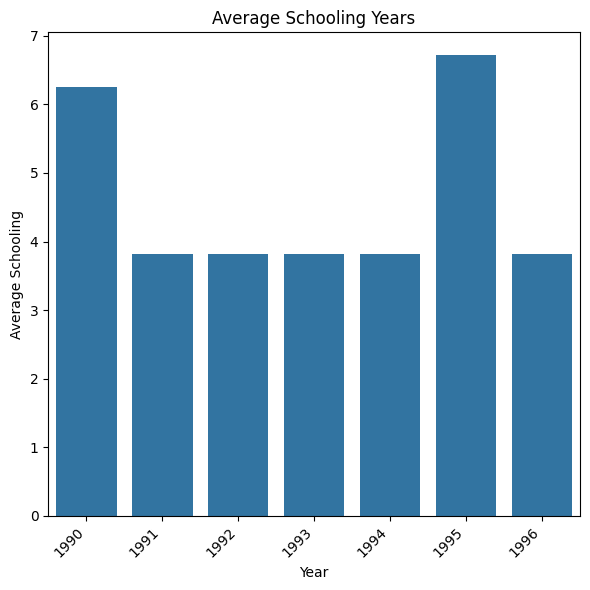

In [ ]:
df=pd.read_sql("""
SELECT year,
avg(youth_adult_yr_edu) as "global avg_schooling"
FROM Gdp_Schooling
GROUP BY year
ORDER BY year;
""",conn)

plt.figure(figsize=(6,6))
sns.barplot(data=df.head(7), x="year", y="global avg_schooling")
plt.title("Average Schooling Years")
plt.xlabel("Year")
plt.ylabel("Average Schooling")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Join Queries
   10. List top 10 countries in 2020 with highest GDP per capita but lowest average years of schooling(less than 6).

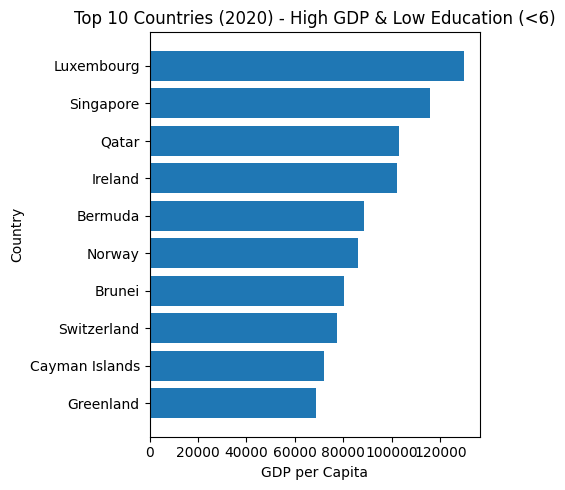

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_sql("""
SELECT
g.Country_A as country, g.year,g.gdp_per_capita,g.youth_adult_yr_edu
FROM Gdp_Schooling g
where g.year = 2020
and g.youth_adult_yr_edu < 6
group by g.Country_A
order by g.gdp_per_capita DESC
LIMIT 10;
""",conn)

plt.figure(figsize=(5,5))
plt.barh(df["country"], df["gdp_per_capita"])

plt.xlabel("GDP per Capita")
plt.ylabel("Country")
plt.title("Top 10 Countries (2020) - High GDP & Low Education (<6)")

plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()
plt.show()

# 11. Show countries where the illiterate population is high despite having more than 10 average years of schooling.

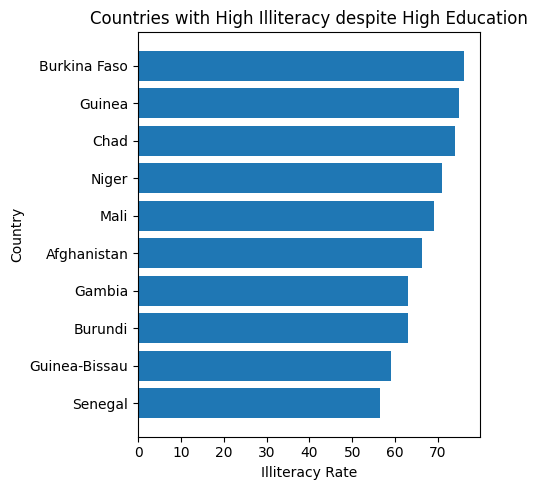

In [ ]:
df = pd.read_sql("""
SELECT
G.Country_A as country,
g.year,g.youth_adult_yr_edu,i.illiteracy_rate
FROM Gdp_Schooling g
join illiteracy_population i
on g.code_x = i.code
and g.year = i.year
where g.youth_adult_yr_edu > 10
and i.illiteracy_rate > 20
group by g.Country_A
order by i.illiteracy_rate desc
LIMIT 10;
""",conn)

plt.figure(figsize=(5,5))
plt.barh(df["country"], df["illiteracy_rate"])

plt.xlabel("Illiteracy Rate")
plt.ylabel("Country")
plt.title("Countries with High Illiteracy despite High Education")

plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()
plt.show()

#    12. Compare literacy rates and GDP per capita growth for a selected country over the last 20 years. (country of your choice)

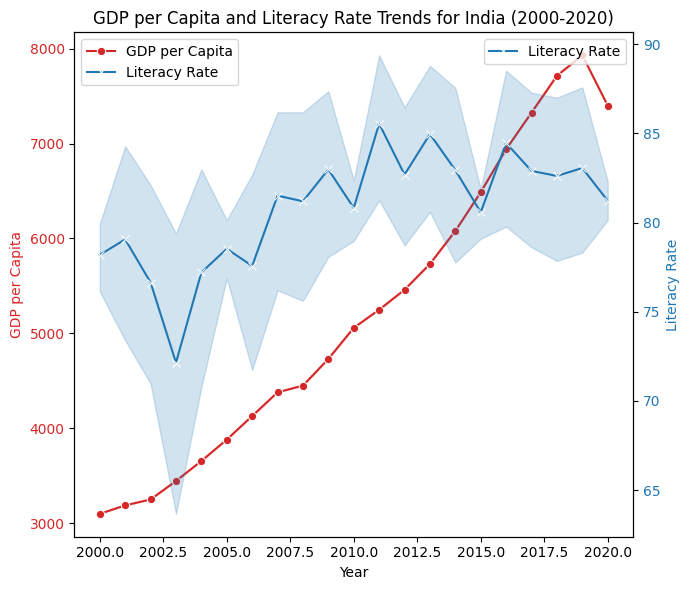

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_sql("""
SELECT
g.year,g.gdp_per_capita,g.literacy_rate
FROM Gdp_Schooling g
where g.Country_A = 'India'
and g.year >= 2000 and g.year <= 2020
order by g.year;
""",conn)

fig, ax1 = plt.subplots(figsize=(7, 6))

color = 'tab:red'
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP per Capita', color=color)
sns.lineplot(x='year', y='gdp_per_capita', data=df, ax=ax1, color=color, marker='o', label='GDP per Capita')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()

color = 'tab:blue'
ax2.set_ylabel('Literacy Rate', color=color)
sns.lineplot(x='year', y='literacy_rate', data=df, ax=ax2, color=color, marker='x', label='Literacy Rate')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('GDP per Capita and Literacy Rate Trends for India (2000-2020)')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
# Add custom legends to both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')
plt.show()


#  13. Show the difference between youth literacy male and female rates for countries with GDP per capita above $30,000 in 2020.

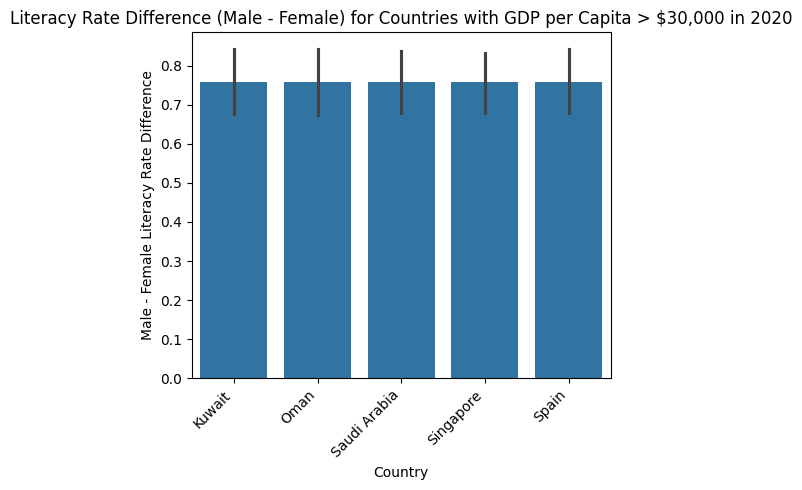

In [ ]:
df=pd.read_sql("""
SELECT
    g.Country_A AS country,
    g.gdp_per_capita,
    l.male AS male_literacy_rate,
    l.female AS female_literacy_rate,
    (l.male - l.female) AS literacy_gap
FROM Gdp_Schooling g
JOIN Literacy_rates l -- Corrected table name from 'Literacy_rate' to 'Literacy_rates'
    ON g.code_x = l.code_x
    AND g.year = l.year
WHERE g.year = 2020
  AND g.gdp_per_capita > 30000
ORDER BY literacy_gap DESC;
""",conn)

plt.figure(figsize=(5, 5))
sns.barplot(x='country', y='literacy_gap', data=df)
plt.title('Literacy Rate Difference (Male - Female) for Countries with GDP per Capita > $30,000 in 2020')
plt.xlabel('Country')
plt.ylabel('Male - Female Literacy Rate Difference')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
